In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [32]:
input_dir = Path('/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1')

particle= xr.open_zarr(input_dir / "local_polar_particle.zarr")
bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_28899/2562907557.py:3: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  particle= xr.open_zarr(input_dir / "local_polar_particle.zarr")
/Users/sasakinozomu/code/MTCargo_analysis/.pixi/envs/default/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at ._zarr.json is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/Users/sasakinozomu/code/MTCargo_analysis/.pixi/envs/default/lib/python3.11/site-packages/zarr/core/gro

(0.0, 1.0)

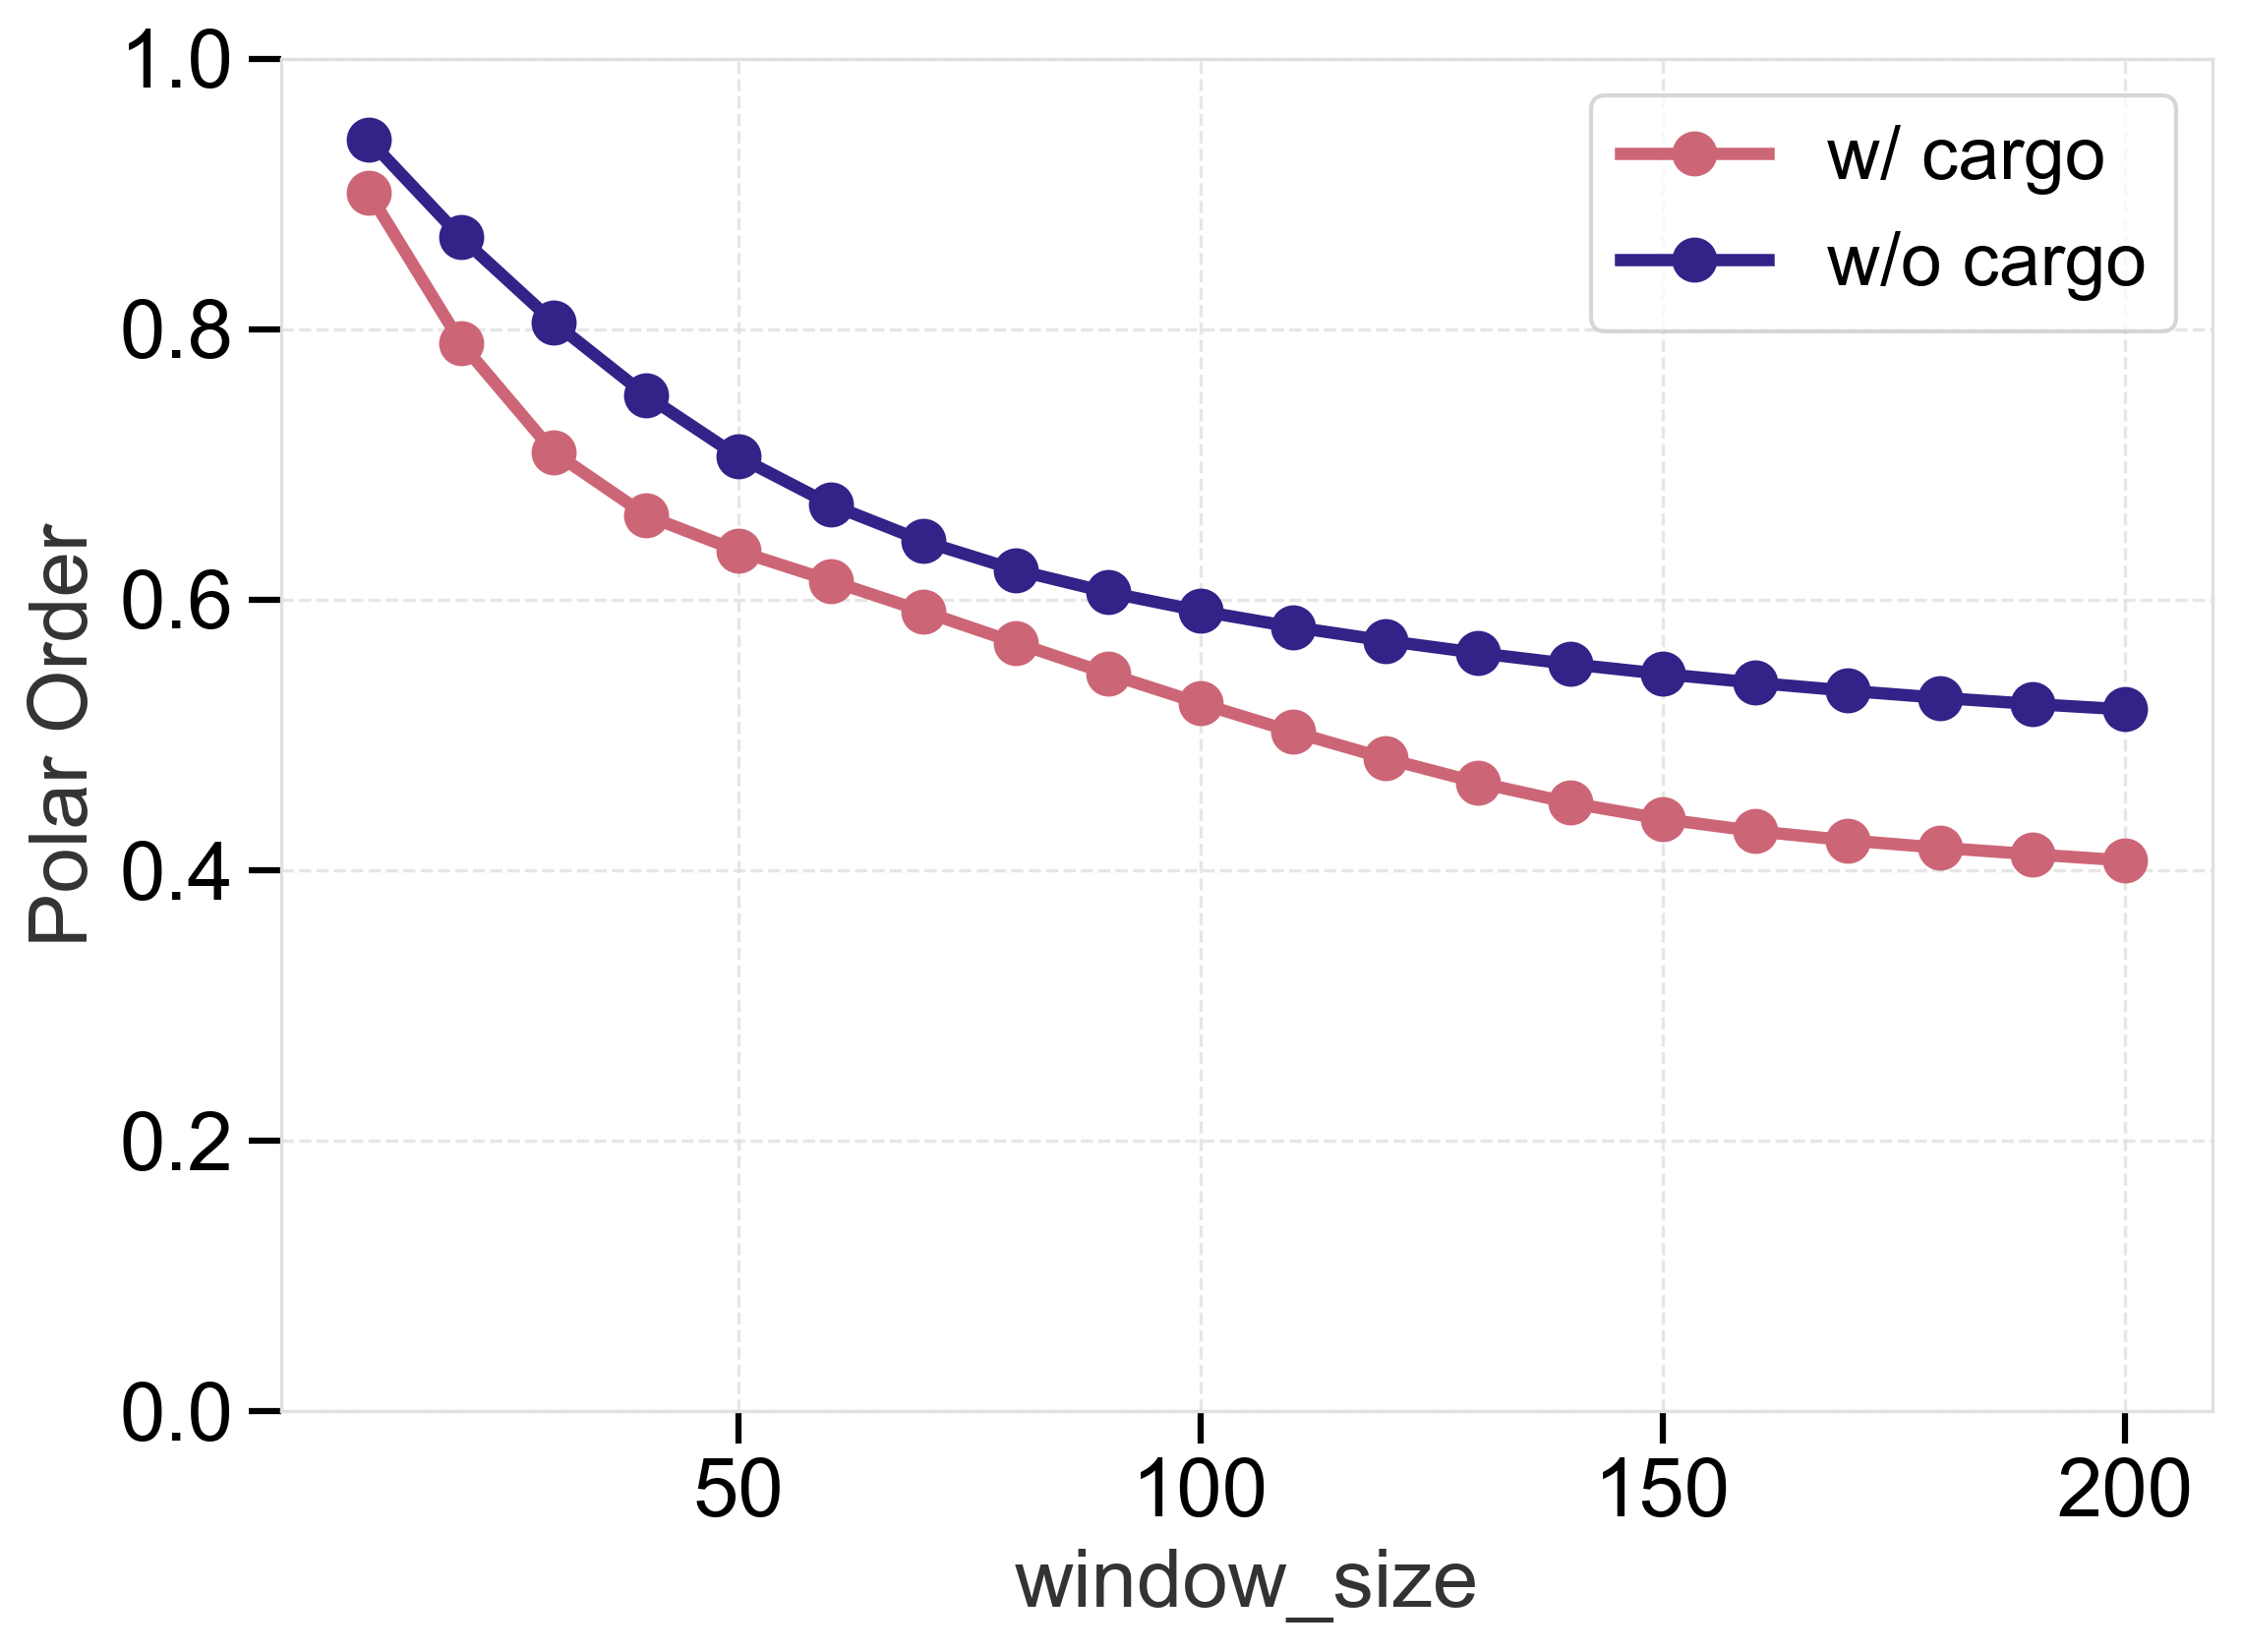

In [33]:
# --- 究極に簡単なプロット ---
plt.figure()
particle.polar_order.mean(dim=['frame', 'particle']).plot(label='w/ cargo', marker='o')
bg.polar_order.mean(dim=['frame', 'particle']).plot(label='w/o cargo', marker='o')

plt.legend()

plt.ylabel("Polar Order")
plt.ylim(0, 1)